# Kidney Stone Segmentation using UNet++

## KSSD2025 Dataset - Kaggle Implementation

This notebook implements a complete training pipeline for kidney stone segmentation using **UNet++** architecture with **ResNet34** encoder on the KSSD2025 dataset.

### Pipeline Overview:
1. **Setup & Configuration** - Install dependencies, set hyperparameters
2. **Data Exploration** - Analyze dataset structure and visualize samples
3. **Dataset & DataLoader** - Custom dataset with augmentation
4. **Model Definition** - UNet++ with ResNet34 encoder (pretrained ImageNet)
5. **Training** - Train with Dice Loss, Early Stopping, Model Checkpointing
6. **Evaluation** - Compute Precision, Recall, IoU, Dice Score
7. **Visualization** - Training curves and prediction results
8. **Inference** - Predict on new images

### Reference:
- Paper: *KSSD2025: A New Annotated Dataset for Automatic Kidney Stone Segmentation and Evaluation With Modified U-Net Based Deep Learning Models* (IEEE Access, 2025)
- Dataset: 838 manually annotated axial CT images

---

## 1. Setup & Environment

In [1]:
# Install required packages (Kaggle environment)
!pip install -q segmentation-models-pytorch albumentations tifffile

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 7.2 MB/s eta 0:00:00


In [2]:
# Import libraries
import os
import random
import numpy as np
import pandas as pd
from glob import glob
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Image processing
import cv2
import tifffile
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-whitegrid')

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Segmentation Models PyTorch
import segmentation_models_pytorch as smp

# Albumentations for augmentation
import albumentations as A
from albumentations.pytorch import ToTensorV2

# Sklearn for data splitting
from sklearn.model_selection import train_test_split

print(f"PyTorch version: {torch.__version__}")
print(f"Segmentation Models PyTorch version: {smp.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.9.0+cu126
Segmentation Models PyTorch version: 0.5.0
CUDA available: True
GPU: Tesla P100-PCIE-16GB


## 2. Configuration

In [8]:
# ============================================
# CONFIGURATION - Modify paths for Kaggle
# ============================================

class Config:
    # Paths - UPDATE THESE FOR YOUR KAGGLE DATASET
    # If dataset is uploaded as "kssd2025", paths would be:
    DATA_DIR = '/kaggle/input/kssd2025-kidney-stone-segmentation-dataset'  # Change this to your dataset path
    IMAGE_DIR = os.path.join(DATA_DIR, 'data', 'image')
    LABEL_DIR = os.path.join(DATA_DIR, 'data', 'label')
    OUTPUT_DIR = '/kaggle/working'
    
    # Model configuration
    MODEL_NAME = 'UNetPlusPlus'
    ENCODER_NAME = 'resnet34'
    ENCODER_WEIGHTS = 'imagenet'
    IN_CHANNELS = 1  # Grayscale input (CT images)
    NUM_CLASSES = 1  # Binary segmentation
    ACTIVATION = None  # Use torch.sigmoid() during inference
    
    # Training hyperparameters (based on KSSD2025 paper)
    IMAGE_SIZE = 512
    BATCH_SIZE = 4  # Reduced to avoid GPU OOM
    EPOCHS = 100
    LEARNING_RATE = 0.0001  # Reduced from 0.001 for stability
    
    # Early stopping
    EARLY_STOP_PATIENCE = 10
    
    # Data split
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    
    # Random seed for reproducibility
    SEED = 42
    
    # Device
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    
    # Number of workers for DataLoader
    NUM_WORKERS = 2

# Set random seeds for reproducibility
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    os.environ['PYTHONHASHSEED'] = str(seed)

set_seed(Config.SEED)

# Print configuration
print("=" * 50)
print("CONFIGURATION")
print("=" * 50)
print(f"Model: {Config.MODEL_NAME} with {Config.ENCODER_NAME} encoder")
print(f"Image Size: {Config.IMAGE_SIZE}x{Config.IMAGE_SIZE}")
print(f"Batch Size: {Config.BATCH_SIZE}")
print(f"Epochs: {Config.EPOCHS}")
print(f"Learning Rate: {Config.LEARNING_RATE}")
print(f"Early Stopping Patience: {Config.EARLY_STOP_PATIENCE}")
print(f"Device: {Config.DEVICE}")
print("=" * 50)

CONFIGURATION
Model: UNetPlusPlus with resnet34 encoder
Image Size: 512x512
Batch Size: 4
Epochs: 100
Learning Rate: 0.0001
Early Stopping Patience: 10
Device: cuda


## 3. Data Exploration

In [9]:
# Check if paths exist and list files
print("Checking data directories...")
print(f"\nImage directory: {Config.IMAGE_DIR}")
print(f"Label directory: {Config.LABEL_DIR}")

# List all available input directories (helpful for Kaggle)
print("\nAvailable input directories:")
if os.path.exists('/kaggle/input'):
    for item in os.listdir('/kaggle/input'):
        print(f"  - /kaggle/input/{item}")
else:
    print("  Not running on Kaggle")

Checking data directories...

Image directory: /kaggle/input/kssd2025-kidney-stone-segmentation-dataset/data/image
Label directory: /kaggle/input/kssd2025-kidney-stone-segmentation-dataset/data/label

Available input directories:
  - /kaggle/input/kssd2025-kidney-stone-segmentation-dataset


In [10]:
# Get all image and label files
image_files = sorted(glob(os.path.join(Config.IMAGE_DIR, '*.tif')))
label_files = sorted(glob(os.path.join(Config.LABEL_DIR, '*.tif')))

print(f"Total image files found: {len(image_files)}")
print(f"Total label files found: {len(label_files)}")

# Get file IDs (without extension)
image_ids = set([os.path.basename(f).replace('.tif', '') for f in image_files])
label_ids = set([os.path.basename(f).replace('.tif', '') for f in label_files])

# Find matched pairs (images that have corresponding labels)
matched_ids = sorted(list(image_ids.intersection(label_ids)), key=lambda x: int(x))
print(f"\nMatched image-label pairs: {len(matched_ids)}")

# Show some sample IDs
print(f"\nSample matched IDs: {matched_ids[:10]}")

Total image files found: 838
Total label files found: 838

Matched image-label pairs: 838

Sample matched IDs: ['1', '2', '3', '4', '5', '6', '7', '8', '9', '10']


In [11]:
# Function to load and display image-mask pairs
def read_tiff(path):
    """Read TIFF with PIL fallback for LZW compression"""
    try:
        return tifffile.imread(path)
    except ValueError as exc:
        if 'COMPRESSION.LZW' in str(exc):
            return np.array(Image.open(path))
        raise

def load_image(path):
    """Load image from path"""
    img = read_tiff(path)
    return img

def load_mask(path):
    """Load mask from path and binarize"""
    mask = read_tiff(path)
    # Ensure binary mask (0 or 1)
    if mask.max() > 1:
        mask = (mask > 0).astype(np.uint8)
    return mask

# Load a sample image and mask to check dimensions
if not matched_ids:
    raise ValueError("No matched image-label pairs found. Check Config.IMAGE_DIR and Config.LABEL_DIR.")
sample_id = matched_ids[0]
sample_image = load_image(os.path.join(Config.IMAGE_DIR, f'{sample_id}.tif'))
sample_mask = load_mask(os.path.join(Config.LABEL_DIR, f'{sample_id}.tif'))

print("Sample Image Info:")
print(f"  Shape: {sample_image.shape}")
print(f"  Dtype: {sample_image.dtype}")
print(f"  Min: {sample_image.min()}, Max: {sample_image.max()}")

print("\nSample Mask Info:")
print(f"  Shape: {sample_mask.shape}")
print(f"  Dtype: {sample_mask.dtype}")
print(f"  Unique values: {np.unique(sample_mask)}")

Sample Image Info:
  Shape: (512, 512)
  Dtype: uint8
  Min: 0, Max: 255

Sample Mask Info:
  Shape: (512, 512)
  Dtype: uint8
  Unique values: [0 1]


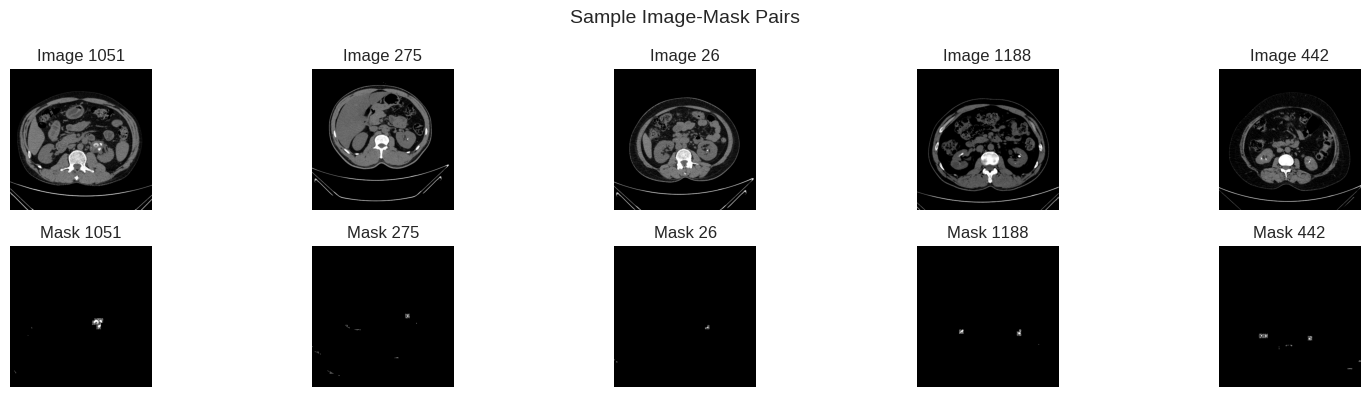

In [12]:
# Visualize sample image-mask pairs
def visualize_samples(ids, n_samples=4, figsize=(16, 4)):
    """Visualize random image-mask pairs"""
    sample_ids = random.sample(ids, min(n_samples, len(ids)))
    
    fig, axes = plt.subplots(2, n_samples, figsize=figsize)
    
    for idx, sample_id in enumerate(sample_ids):
        img = load_image(os.path.join(Config.IMAGE_DIR, f'{sample_id}.tif'))
        mask = load_mask(os.path.join(Config.LABEL_DIR, f'{sample_id}.tif'))
        
        # Handle different image formats
        if len(img.shape) == 2:  # Grayscale
            axes[0, idx].imshow(img, cmap='gray')
        else:  # RGB or other
            axes[0, idx].imshow(img)
        axes[0, idx].set_title(f'Image {sample_id}')
        axes[0, idx].axis('off')
        
        # Show mask
        axes[1, idx].imshow(mask, cmap='gray')
        axes[1, idx].set_title(f'Mask {sample_id}')
        axes[1, idx].axis('off')
    
    plt.suptitle('Sample Image-Mask Pairs', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_samples(matched_ids, n_samples=5)

Analyzing masks:   0%|          | 0/100 [00:00<?, ?it/s]


Mask Statistics (sampled):
  Mean stone pixel ratio: 0.1387%
  Min stone pixel ratio: 0.0111%
  Max stone pixel ratio: 0.4524%
  Median stone pixel count: 294


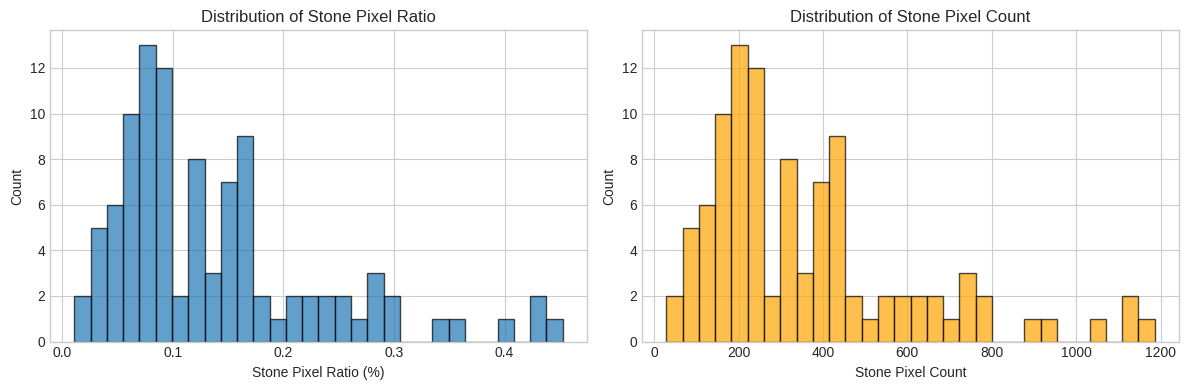

In [13]:
# Analyze mask statistics
def analyze_masks(ids, sample_size=100):
    """Analyze mask pixel distributions"""
    sample_ids = random.sample(ids, min(sample_size, len(ids)))
    
    stone_ratios = []
    stone_counts = []
    
    for sample_id in tqdm(sample_ids, desc="Analyzing masks"):
        mask = load_mask(os.path.join(Config.LABEL_DIR, f'{sample_id}.tif'))
        
        # Calculate stone pixel ratio
        total_pixels = mask.size
        stone_pixels = np.sum(mask > 0)
        ratio = stone_pixels / total_pixels
        stone_ratios.append(ratio * 100)  # Convert to percentage
        stone_counts.append(stone_pixels)
    
    print("\nMask Statistics (sampled):")
    print(f"  Mean stone pixel ratio: {np.mean(stone_ratios):.4f}%")
    print(f"  Min stone pixel ratio: {np.min(stone_ratios):.4f}%")
    print(f"  Max stone pixel ratio: {np.max(stone_ratios):.4f}%")
    print(f"  Median stone pixel count: {np.median(stone_counts):.0f}")
    
    # Plot distribution
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    axes[0].hist(stone_ratios, bins=30, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('Stone Pixel Ratio (%)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Distribution of Stone Pixel Ratio')
    
    axes[1].hist(stone_counts, bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1].set_xlabel('Stone Pixel Count')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Distribution of Stone Pixel Count')
    
    plt.tight_layout()
    plt.show()
    
    return stone_ratios, stone_counts

stone_ratios, stone_counts = analyze_masks(matched_ids)

## 4. Dataset & DataLoader

In [15]:
# Define Data Augmentation transforms (based on KSSD2025 paper)
def get_train_transforms(image_size):
    """Training augmentations based on KSSD2025 paper"""
    return A.Compose([
        A.Resize(image_size, image_size),
        # Paper augmentations (light augmentation)
        A.Rotate(limit=2.5, p=0.5),  # Rotation: up to 2.5 degrees
        A.ShiftScaleRotate(
            shift_limit=0.0075,  # Width/Height shift: up to 0.75%
            scale_limit=0.0075,  # Zoom: up to 0.75%
            rotate_limit=0,
            p=0.5
        ),
        A.GaussNoise(var_limit=(0.0, 0.0075), p=0.3),  # Noise range: up to 0.75%
        A.HorizontalFlip(p=0.5),  # Horizontal flip: enabled
        # Normalize for pretrained encoder (ImageNet stats)
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0
        ),
        ToTensorV2()
    ])

def get_val_transforms(image_size):
    """Validation/Test transforms (no augmentation)"""
    return A.Compose([
        A.Resize(image_size, image_size),
        A.Normalize(
            mean=[0.485, 0.456, 0.406],
            std=[0.229, 0.224, 0.225],
            max_pixel_value=255.0
        ),
        ToTensorV2()
    ])

In [16]:
# Custom Dataset class
class KidneyStoneDataset(Dataset):
    """Dataset for Kidney Stone Segmentation (Grayscale)"""
    
    def __init__(self, image_ids, image_dir, label_dir, image_size=512):
        self.image_ids = image_ids
        self.image_dir = image_dir
        self.label_dir = label_dir
        self.image_size = image_size
    
    def __len__(self):
        return len(self.image_ids)
    
    def __getitem__(self, idx):
        image_id = self.image_ids[idx]
        
        # Load image as grayscale using cv2
        image_path = os.path.join(self.image_dir, f'{image_id}.tif')
        image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        # Load mask as grayscale
        mask_path = os.path.join(self.label_dir, f'{image_id}.tif')
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        # Resize if needed
        if image.shape[0] != self.image_size or image.shape[1] != self.image_size:
            image = cv2.resize(image, (self.image_size, self.image_size))
            mask = cv2.resize(mask, (self.image_size, self.image_size))
        
        # Normalize to [0, 1] - simple division by 255
        image = image.astype(np.float32) / 255.0
        mask = mask.astype(np.float32) / 255.0
        
        # Convert to tensor and add channel dimension
        image = torch.from_numpy(image).unsqueeze(0)  # (1, H, W)
        mask = torch.from_numpy(mask).unsqueeze(0)    # (1, H, W)
        
        return image, mask, image_id

In [17]:
# Split data into train/val/test sets
def split_data(ids, train_ratio, val_ratio, test_ratio, seed):
    """Split data into train/val/test sets"""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6, "Ratios must sum to 1"
    
    # First split: train vs (val + test)
    train_ids, temp_ids = train_test_split(
        ids, 
        train_size=train_ratio, 
        random_state=seed
    )
    
    # Second split: val vs test
    val_ratio_adjusted = val_ratio / (val_ratio + test_ratio)
    val_ids, test_ids = train_test_split(
        temp_ids, 
        train_size=val_ratio_adjusted, 
        random_state=seed
    )
    
    return train_ids, val_ids, test_ids

# Perform split
train_ids, val_ids, test_ids = split_data(
    matched_ids,
    Config.TRAIN_RATIO,
    Config.VAL_RATIO,
    Config.TEST_RATIO,
    Config.SEED
)

print(f"Data Split:")
print(f"  Train: {len(train_ids)} samples ({len(train_ids)/len(matched_ids)*100:.1f}%)")
print(f"  Val: {len(val_ids)} samples ({len(val_ids)/len(matched_ids)*100:.1f}%)")
print(f"  Test: {len(test_ids)} samples ({len(test_ids)/len(matched_ids)*100:.1f}%)")
print(f"  Total: {len(train_ids) + len(val_ids) + len(test_ids)} samples")

Data Split:
  Train: 586 samples (69.9%)
  Val: 126 samples (15.0%)
  Test: 126 samples (15.0%)
  Total: 838 samples


In [18]:
# Create datasets and dataloaders
train_dataset = KidneyStoneDataset(
    train_ids, 
    Config.IMAGE_DIR, 
    Config.LABEL_DIR,
    image_size=Config.IMAGE_SIZE
)

val_dataset = KidneyStoneDataset(
    val_ids, 
    Config.IMAGE_DIR, 
    Config.LABEL_DIR,
    image_size=Config.IMAGE_SIZE
)

test_dataset = KidneyStoneDataset(
    test_ids, 
    Config.IMAGE_DIR, 
    Config.LABEL_DIR,
    image_size=Config.IMAGE_SIZE
)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True,
    drop_last=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False,
    num_workers=Config.NUM_WORKERS,
    pin_memory=True
)

print(f"\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches: {len(val_loader)}")
print(f"  Test batches: {len(test_loader)}")


DataLoaders created:
  Train batches: 146
  Val batches: 32
  Test batches: 32


In [19]:
# Verify data loading
def verify_dataloader(loader, name="Dataset"):
    """Verify dataloader outputs"""
    images, masks, ids = next(iter(loader))
    print(f"\n{name}:")
    print(f"  Images shape: {images.shape}")
    print(f"  Masks shape: {masks.shape}")
    print(f"  Images dtype: {images.dtype}")
    print(f"  Masks dtype: {masks.dtype}")
    print(f"  Images range: [{images.min():.4f}, {images.max():.4f}]")
    print(f"  Masks unique values: {torch.unique(masks).numpy()}")
    return images, masks, ids

train_images, train_masks, train_batch_ids = verify_dataloader(train_loader, "Train DataLoader")
val_images, val_masks, val_batch_ids = verify_dataloader(val_loader, "Val DataLoader")


Train DataLoader:
  Images shape: torch.Size([4, 1, 512, 512])
  Masks shape: torch.Size([4, 1, 512, 512])
  Images dtype: torch.float32
  Masks dtype: torch.float32
  Images range: [0.0000, 1.0000]
  Masks unique values: [0.         0.00392157 0.00784314 0.01176471 0.01568628 0.01960784
 0.02352941 0.02745098 0.972549   0.9764706  0.98039216 0.9843137
 0.9882353  0.99215686 0.99607843 1.        ]

Val DataLoader:
  Images shape: torch.Size([4, 1, 512, 512])
  Masks shape: torch.Size([4, 1, 512, 512])
  Images dtype: torch.float32
  Masks dtype: torch.float32
  Images range: [0.0000, 1.0000]
  Masks unique values: [0.         0.00392157 0.00784314 0.01176471 0.01568628 0.01960784
 0.02352941 0.02745098 0.972549   0.98039216 0.9843137  0.9882353
 0.99215686 0.99607843 1.        ]


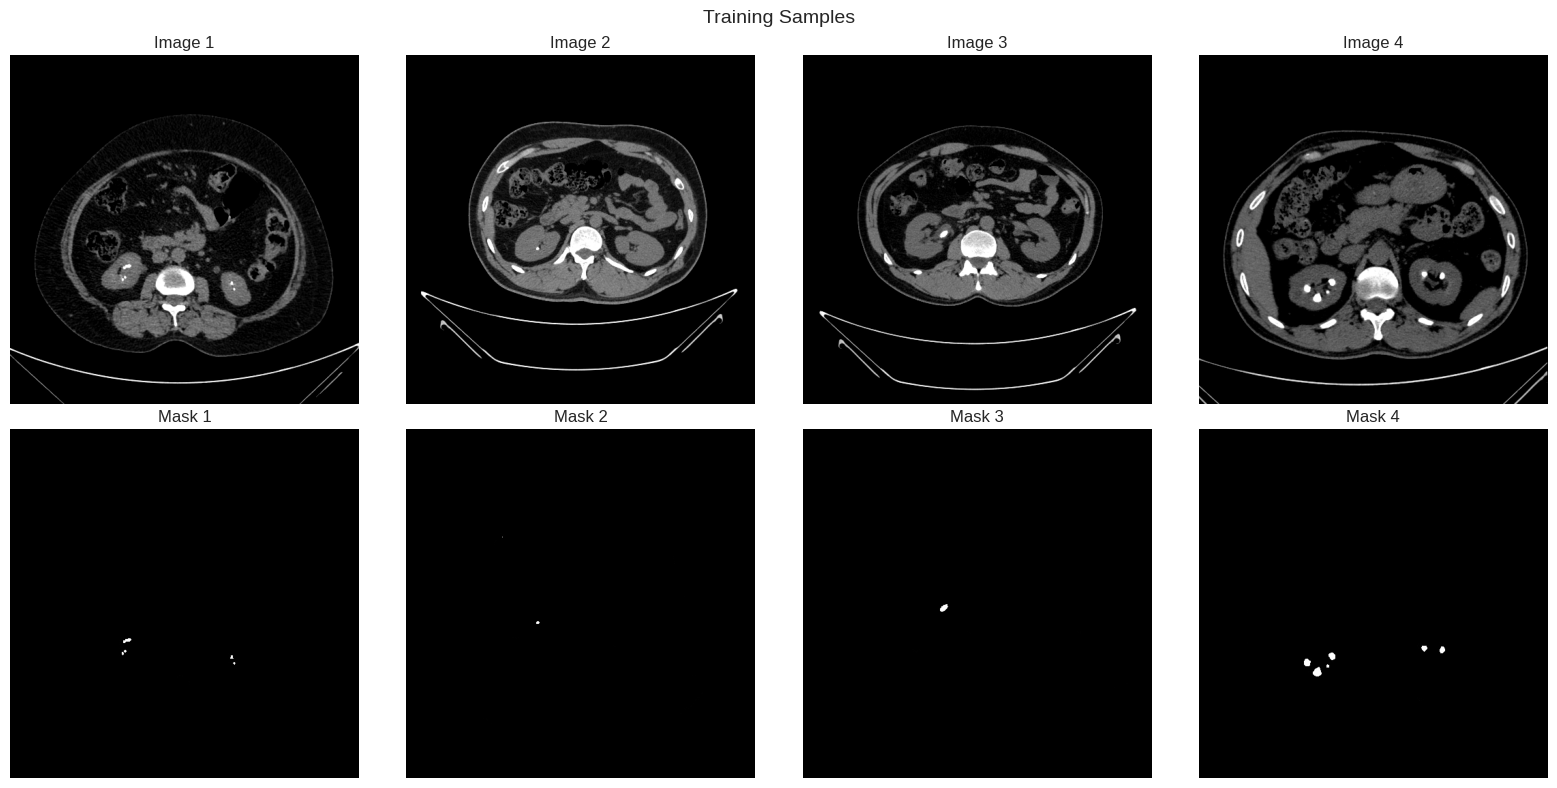

In [20]:
# Visualize samples (grayscale)
def visualize_batch(images, masks, n_samples=4):
    """Visualize batch of images and masks"""
    fig, axes = plt.subplots(2, n_samples, figsize=(4*n_samples, 8))
    
    for i in range(min(n_samples, len(images))):
        # Show image (grayscale, already normalized to [0, 1])
        img = images[i].squeeze().numpy()
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f'Image {i+1}')
        axes[0, i].axis('off')
        
        # Show mask
        mask = masks[i].squeeze().numpy()
        axes[1, i].imshow(mask, cmap='gray')
        axes[1, i].set_title(f'Mask {i+1}')
        axes[1, i].axis('off')
    
    plt.suptitle('Training Samples', fontsize=14)
    plt.tight_layout()
    plt.show()

visualize_batch(train_images, train_masks, n_samples=4)

## 5. Model Definition

In [21]:
# Create UNet++ model with ResNet34 encoder
def create_model(config):
    """Create UNet++ model with specified configuration"""
    model = smp.UnetPlusPlus(
        encoder_name=config.ENCODER_NAME,
        encoder_weights=config.ENCODER_WEIGHTS,
        in_channels=config.IN_CHANNELS,
        classes=config.NUM_CLASSES,
        activation=config.ACTIVATION
    )
    return model

# Initialize model
model = create_model(Config)
model = model.to(Config.DEVICE)

# Print model summary
def count_parameters(model):
    """Count trainable parameters"""
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total_params, trainable_params

total_params, trainable_params = count_parameters(model)
print(f"\nModel: {Config.MODEL_NAME}")
print(f"Encoder: {Config.ENCODER_NAME} (pretrained: {Config.ENCODER_WEIGHTS})")
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print(f"Model size: {total_params * 4 / 1024 / 1024:.2f} MB (float32)")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]


Model: UNetPlusPlus
Encoder: resnet34 (pretrained: imagenet)
Total parameters: 26,072,337
Trainable parameters: 26,072,337
Model size: 99.46 MB (float32)


In [22]:
# Test forward pass
with torch.no_grad():
    test_input = torch.randn(1, 1, Config.IMAGE_SIZE, Config.IMAGE_SIZE).to(Config.DEVICE)  # 1 channel (grayscale)
    test_output = model(test_input)
    print(f"\nForward pass test:")
    print(f"  Input shape: {test_input.shape}")
    print(f"  Output shape: {test_output.shape}")
    print(f"  Output range (logits): [{test_output.min():.4f}, {test_output.max():.4f}]")
    print(f"  Output range (sigmoid): [{torch.sigmoid(test_output).min():.4f}, {torch.sigmoid(test_output).max():.4f}]")


Forward pass test:
  Input shape: torch.Size([1, 1, 512, 512])
  Output shape: torch.Size([1, 1, 512, 512])
  Output range (logits): [-6.9586, 3.9783]
  Output range (sigmoid): [0.0009, 0.9816]


## 6. Loss Function & Metrics

In [23]:
# Dice Loss (as used in the KSSD2025 paper)
class DiceLoss(nn.Module):
    """Dice Loss for binary segmentation"""
    
    def __init__(self, smooth=1e-6):
        super(DiceLoss, self).__init__()
        self.smooth = smooth
    
    def forward(self, pred, target):
        # Flatten predictions and targets
        pred_flat = pred.view(-1)
        target_flat = target.view(-1)
        
        # Calculate Dice coefficient
        intersection = (pred_flat * target_flat).sum()
        dice = (2. * intersection + self.smooth) / (
            pred_flat.sum() + target_flat.sum() + self.smooth
        )
        
        return 1 - dice

# Combined Loss (optional: Dice + BCE)
class CombinedLoss(nn.Module):
    """Combined Dice + BCE Loss"""
    
    def __init__(self, dice_weight=0.5, bce_weight=0.5):
        super(CombinedLoss, self).__init__()
        self.dice_loss = DiceLoss()
        self.bce_loss = nn.BCELoss()
        self.dice_weight = dice_weight
        self.bce_weight = bce_weight
    
    def forward(self, pred, target):
        dice = self.dice_loss(pred, target)
        bce = self.bce_loss(pred, target)
        return self.dice_weight * dice + self.bce_weight * bce

# Use smp.losses.DiceLoss for better optimization
# Note: Since model has no activation, we use from_logits=True
criterion = smp.losses.DiceLoss(mode='binary', from_logits=True)
print("Loss function: smp.losses.DiceLoss (mode='binary', from_logits=True)")

Loss function: smp.losses.DiceLoss (mode='binary', from_logits=True)


In [24]:
# Evaluation Metrics (as defined in the paper)
class SegmentationMetrics:
    """Calculate segmentation metrics: Precision, Recall, Jaccard (IoU), Dice"""
    
    def __init__(self, threshold=0.5, smooth=1e-6, from_logits=True):
        self.threshold = threshold
        self.smooth = smooth
        self.from_logits = from_logits
    
    def __call__(self, pred, target):
        """Calculate all metrics"""
        # Apply sigmoid if predictions are logits
        if self.from_logits:
            pred = torch.sigmoid(pred)
        
        # Binarize predictions
        pred_binary = (pred > self.threshold).float()
        
        # Flatten
        pred_flat = pred_binary.view(-1)
        target_flat = target.view(-1)
        
        # Calculate TP, FP, FN
        tp = (pred_flat * target_flat).sum()
        fp = (pred_flat * (1 - target_flat)).sum()
        fn = ((1 - pred_flat) * target_flat).sum()
        
        # Calculate metrics
        precision = (tp + self.smooth) / (tp + fp + self.smooth)
        recall = (tp + self.smooth) / (tp + fn + self.smooth)
        jaccard = (tp + self.smooth) / (tp + fp + fn + self.smooth)
        dice = (2 * tp + self.smooth) / (2 * tp + fp + fn + self.smooth)
        
        return {
            'precision': precision.item(),
            'recall': recall.item(),
            'jaccard': jaccard.item(),
            'dice': dice.item()
        }

metrics_calculator = SegmentationMetrics(threshold=0.5, from_logits=True)

# Test metrics calculation
print("\nMetrics test:")
with torch.no_grad():
    test_pred = torch.rand(1, 1, 512, 512)
    test_target = (torch.rand(1, 1, 512, 512) > 0.5).float()
    metrics = metrics_calculator(test_pred, test_target)
    for name, value in metrics.items():
        print(f"  {name.capitalize()}: {value:.4f}")


Metrics test:
  Precision: 0.5000
  Recall: 1.0000
  Jaccard: 0.5000
  Dice: 0.6667


In [25]:
# Optimizer (Adam with lr=0.001 as per paper)
optimizer = optim.Adam(model.parameters(), lr=Config.LEARNING_RATE)

# Learning rate scheduler (optional but helpful)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    factor=0.5, 
    patience=5
)

print(f"Optimizer: Adam (lr={Config.LEARNING_RATE})")
print(f"Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)")

Optimizer: Adam (lr=0.0001)
Scheduler: ReduceLROnPlateau (factor=0.5, patience=5)


## 7. Training Loop

In [26]:
# Training and validation functions
def train_one_epoch(model, loader, criterion, optimizer, device, metrics_calculator):
    """Train for one epoch"""
    model.train()
    
    running_loss = 0.0
    all_metrics = {'precision': [], 'recall': [], 'jaccard': [], 'dice': []}
    
    pbar = tqdm(loader, desc="Training", leave=False)
    for images, masks, _ in pbar:
        images = images.to(device)
        masks = masks.to(device)
        
        # Zero gradients
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(images)
        
        # Calculate loss
        loss = criterion(outputs, masks)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Update metrics
        running_loss += loss.item() * images.size(0)
        
        # Calculate batch metrics
        with torch.no_grad():
            batch_metrics = metrics_calculator(outputs, masks)
            for key in all_metrics:
                all_metrics[key].append(batch_metrics[key])
        
        pbar.set_postfix({'loss': loss.item(), 'dice': batch_metrics['dice']})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = {key: np.mean(values) for key, values in all_metrics.items()}
    
    return epoch_loss, epoch_metrics


def validate(model, loader, criterion, device, metrics_calculator):
    """Validate the model"""
    model.eval()
    
    running_loss = 0.0
    all_metrics = {'precision': [], 'recall': [], 'jaccard': [], 'dice': []}
    
    with torch.no_grad():
        pbar = tqdm(loader, desc="Validating", leave=False)
        for images, masks, _ in pbar:
            images = images.to(device)
            masks = masks.to(device)
            
            # Forward pass
            outputs = model(images)
            
            # Calculate loss
            loss = criterion(outputs, masks)
            
            # Update metrics
            running_loss += loss.item() * images.size(0)
            
            # Calculate batch metrics
            batch_metrics = metrics_calculator(outputs, masks)
            for key in all_metrics:
                all_metrics[key].append(batch_metrics[key])
            
            pbar.set_postfix({'loss': loss.item(), 'dice': batch_metrics['dice']})
    
    # Calculate epoch metrics
    epoch_loss = running_loss / len(loader.dataset)
    epoch_metrics = {key: np.mean(values) for key, values in all_metrics.items()}
    
    return epoch_loss, epoch_metrics

In [27]:
# Early Stopping class
class EarlyStopping:
    """Early stopping to stop training when validation loss doesn't improve"""
    
    def __init__(self, patience=10, min_delta=0, verbose=True):
        self.patience = patience
        self.min_delta = min_delta
        self.verbose = verbose
        self.counter = 0
        self.best_loss = None
        self.early_stop = False
    
    def __call__(self, val_loss):
        if self.best_loss is None:
            self.best_loss = val_loss
        elif val_loss > self.best_loss - self.min_delta:
            self.counter += 1
            if self.verbose:
                print(f"  EarlyStopping counter: {self.counter}/{self.patience}")
            if self.counter >= self.patience:
                self.early_stop = True
        else:
            self.best_loss = val_loss
            self.counter = 0

In [28]:
# Main training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler,
                device, epochs, patience, save_path):
    """Complete training loop with early stopping and model checkpointing"""
    
    # Initialize tracking
    history = {
        'train_loss': [], 'val_loss': [],
        'train_dice': [], 'val_dice': [],
        'train_precision': [], 'val_precision': [],
        'train_recall': [], 'val_recall': [],
        'train_jaccard': [], 'val_jaccard': []
    }
    
    best_val_loss = float('inf')
    best_val_dice = 0.0
    early_stopping = EarlyStopping(patience=patience, verbose=True)
    metrics_calc = SegmentationMetrics(threshold=0.5, from_logits=True)
    
    print("=" * 60)
    print("TRAINING STARTED")
    print("=" * 60)
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        print("-" * 40)
        
        # Train
        train_loss, train_metrics = train_one_epoch(
            model, train_loader, criterion, optimizer, device, metrics_calc
        )
        
        # Validate
        val_loss, val_metrics = validate(
            model, val_loader, criterion, device, metrics_calc
        )
        
        # Update scheduler
        scheduler.step(val_loss)
        
        # Update history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_dice'].append(train_metrics['dice'])
        history['val_dice'].append(val_metrics['dice'])
        history['train_precision'].append(train_metrics['precision'])
        history['val_precision'].append(val_metrics['precision'])
        history['train_recall'].append(train_metrics['recall'])
        history['val_recall'].append(val_metrics['recall'])
        history['train_jaccard'].append(train_metrics['jaccard'])
        history['val_jaccard'].append(val_metrics['jaccard'])
        
        # Print epoch results
        print(f"  Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
        print(f"  Train Dice: {train_metrics['dice']:.4f} | Val Dice: {val_metrics['dice']:.4f}")
        print(f"  Train IoU: {train_metrics['jaccard']:.4f} | Val IoU: {val_metrics['jaccard']:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_dice = val_metrics['dice']
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'val_loss': val_loss,
                'val_dice': val_metrics['dice'],
                'val_metrics': val_metrics
            }, save_path)
            print(f"  [SAVED] Best model (val_loss: {val_loss:.4f}, dice: {val_metrics['dice']:.4f})")
        
        # Early stopping check
        early_stopping(val_loss)
        if early_stopping.early_stop:
            print(f"\n[EARLY STOPPING] Training stopped at epoch {epoch+1}")
            break
    
    print("\n" + "=" * 60)
    print("TRAINING COMPLETED")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    print(f"Best Val Dice: {best_val_dice:.4f}")
    print("=" * 60)
    
    return history

In [ ]:
# Start training
MODEL_SAVE_PATH = os.path.join(Config.OUTPUT_DIR, 'best_unetpp_model.pth')

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    scheduler=scheduler,
    device=Config.DEVICE,
    epochs=Config.EPOCHS,
    patience=Config.EARLY_STOP_PATIENCE,
    save_path=MODEL_SAVE_PATH
)

TRAINING STARTED

Epoch 1/100
----------------------------------------


Training:   0%|          | 0/146 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss: 0.9881 | Val Loss: 0.9834
  Train Dice: 0.1064 | Val Dice: 0.3839
  Train IoU: 0.0606 | Val IoU: 0.2390
  LR: 0.000100
  [SAVED] Best model (val_loss: 0.9834, dice: 0.3839)

Epoch 2/100
----------------------------------------


Training:   0%|          | 0/146 [00:00<?, ?it/s]

...

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

  Train Loss: 0.0090 | Val Loss: 0.0300
  Train Dice: 0.9913 | Val Dice: 0.9706
  Train IoU: 0.9829 | Val IoU: 0.9432
  LR: 0.000025
  EarlyStopping counter: 9/10

Epoch 64/100
----------------------------------------


Training:   0%|          | 0/146 [00:00<?, ?it/s]

Validating:   0%|          | 0/32 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3b9fbca7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d3b9fbca7a0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

In [30]:
# Check if the history object was returned
if 'history' in locals():
    print(f"Training finished at epoch {len(history['train_loss'])}")
    print(f"Final Validation Dice: {history['val_dice'][-1]:.4f}")

# Check if the best model was saved
if os.path.exists(MODEL_SAVE_PATH):
    print("Success! Your best model weights are saved and ready for the final report.")

Training finished at epoch 64
Final Validation Dice: 0.9714
Success! Your best model weights are saved and ready for the final report.


## 8. Evaluation

In [31]:
# Load best model
checkpoint = torch.load(MODEL_SAVE_PATH, map_location=Config.DEVICE, weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"  Val Loss: {checkpoint['val_loss']:.4f}")
print(f"  Val Dice: {checkpoint['val_dice']:.4f}")

Loaded best model from epoch 54
  Val Loss: 0.0293
  Val Dice: 0.9722


In [32]:
# Evaluate on test set
def evaluate_test(model, test_loader, criterion, device, metrics_calculator):
    """Final evaluation on test set"""
    model.eval()
    
    all_preds = []
    all_targets = []
    all_ids = []
    running_loss = 0.0
    
    sample_metrics = []
    
    with torch.no_grad():
        for images, masks, ids in tqdm(test_loader, desc="Evaluating Test Set"):
            images = images.to(device)
            masks = masks.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, masks)
            running_loss += loss.item() * images.size(0)
            
            # Store predictions
            all_preds.append(outputs.cpu())
            all_targets.append(masks.cpu())
            all_ids.extend(ids)
            
            # Calculate per-sample metrics
            for i in range(len(ids)):
                m = metrics_calculator(
                    outputs[i:i+1].cpu(),
                    masks[i:i+1].cpu()
                )
                m['id'] = ids[i]
                sample_metrics.append(m)
    
    # Concatenate all predictions
    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)
    
    # Calculate overall metrics
    overall_metrics = metrics_calculator(all_preds, all_targets)
    test_loss = running_loss / len(test_loader.dataset)
    
    return test_loss, overall_metrics, sample_metrics, all_preds, all_targets, all_ids

# Run evaluation
metrics_calc = SegmentationMetrics(threshold=0.5, from_logits=True)
test_loss, test_metrics, sample_metrics, test_preds, test_targets, test_ids = evaluate_test(
    model, test_loader, criterion, Config.DEVICE, metrics_calc
)

Evaluating Test Set:   0%|          | 0/32 [00:00<?, ?it/s]

In [33]:
# Display test results
print("\n" + "=" * 60)
print("TEST SET RESULTS")
print("=" * 60)
print(f"Test Loss: {test_loss:.4f}")
print(f"\nMetrics:")
print(f"  Precision: {test_metrics['precision']*100:.2f}%")
print(f"  Recall: {test_metrics['recall']*100:.2f}%")
print(f"  Jaccard (IoU): {test_metrics['jaccard']*100:.2f}%")
print(f"  Dice Score: {test_metrics['dice']*100:.2f}%")
print("=" * 60)

# Create metrics dataframe
metrics_df = pd.DataFrame(sample_metrics)
print(f"\nPer-sample statistics:")
print(metrics_df[['precision', 'recall', 'jaccard', 'dice']].describe())


TEST SET RESULTS
Test Loss: 0.0366

Metrics:
  Precision: 97.23%
  Recall: 96.92%
  Jaccard (IoU): 94.32%
  Dice Score: 97.08%

Per-sample statistics:
        precision      recall     jaccard        dice
count  126.000000  126.000000  126.000000  126.000000
mean     0.960498    0.928589    0.893521    0.940505
std      0.061287    0.088800    0.099213    0.062951
min      0.538562    0.470914    0.470914    0.640301
25%      0.954417    0.921340    0.881376    0.936948
50%      0.975886    0.965583    0.929922    0.963689
75%      0.993302    0.979030    0.954612    0.976779
max      1.000000    0.997217    0.984653    0.992267


## 9. Visualization

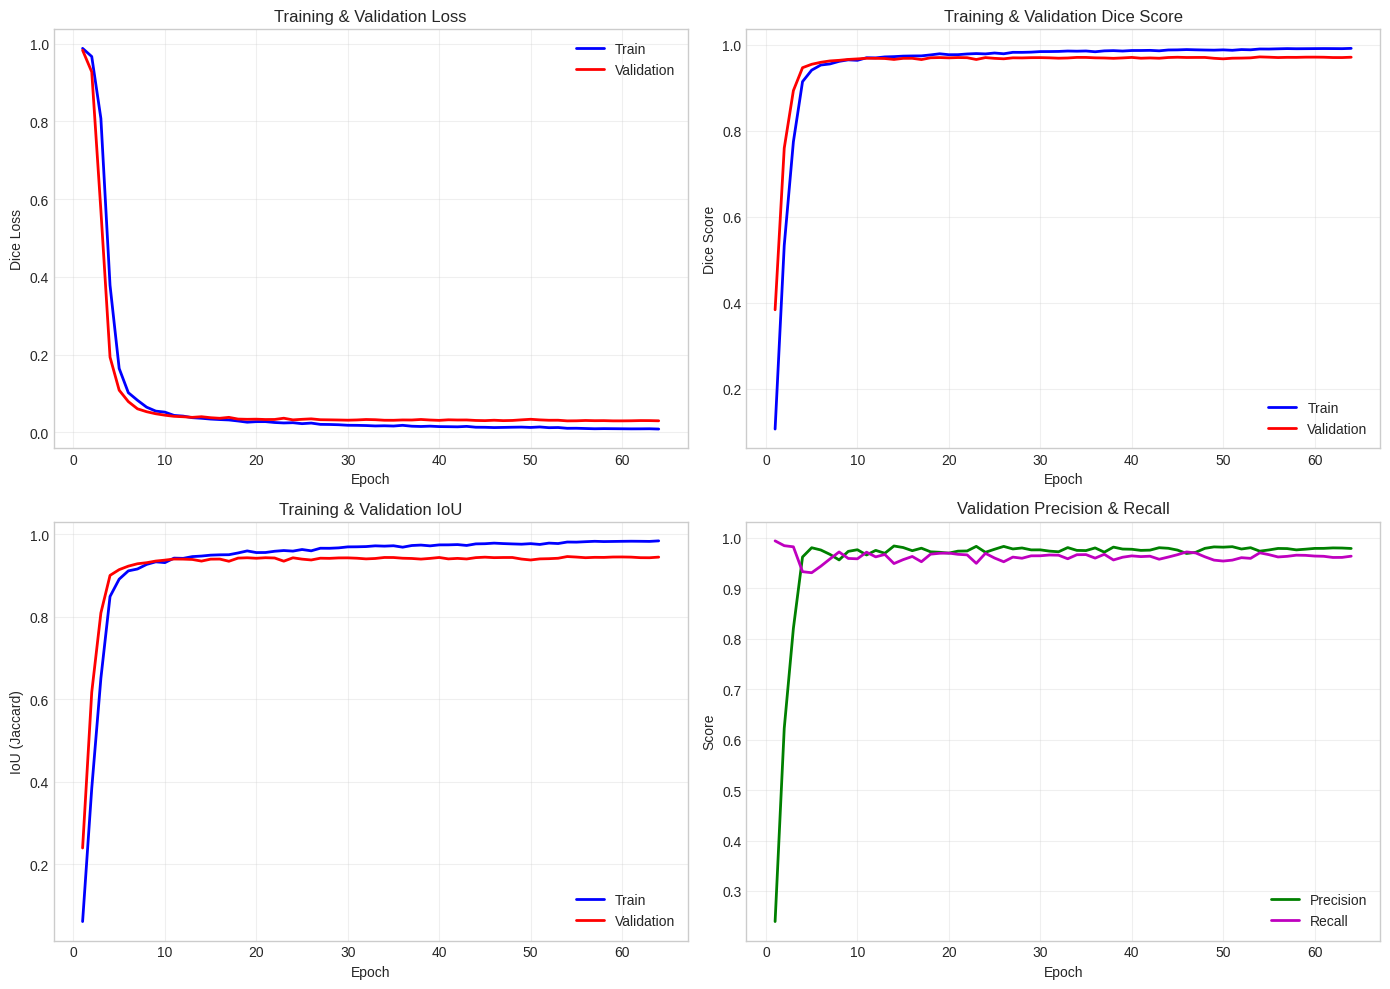

In [34]:
# Plot training history
def plot_training_history(history):
    """Plot training and validation curves"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    epochs = range(1, len(history['train_loss']) + 1)
    
    # Loss
    axes[0, 0].plot(epochs, history['train_loss'], 'b-', label='Train', linewidth=2)
    axes[0, 0].plot(epochs, history['val_loss'], 'r-', label='Validation', linewidth=2)
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Dice Loss')
    axes[0, 0].set_title('Training & Validation Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Dice Score
    axes[0, 1].plot(epochs, history['train_dice'], 'b-', label='Train', linewidth=2)
    axes[0, 1].plot(epochs, history['val_dice'], 'r-', label='Validation', linewidth=2)
    axes[0, 1].set_xlabel('Epoch')
    axes[0, 1].set_ylabel('Dice Score')
    axes[0, 1].set_title('Training & Validation Dice Score')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # IoU (Jaccard)
    axes[1, 0].plot(epochs, history['train_jaccard'], 'b-', label='Train', linewidth=2)
    axes[1, 0].plot(epochs, history['val_jaccard'], 'r-', label='Validation', linewidth=2)
    axes[1, 0].set_xlabel('Epoch')
    axes[1, 0].set_ylabel('IoU (Jaccard)')
    axes[1, 0].set_title('Training & Validation IoU')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Precision & Recall
    axes[1, 1].plot(epochs, history['val_precision'], 'g-', label='Precision', linewidth=2)
    axes[1, 1].plot(epochs, history['val_recall'], 'm-', label='Recall', linewidth=2)
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].set_ylabel('Score')
    axes[1, 1].set_title('Validation Precision & Recall')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
    plt.show()

plot_training_history(history)

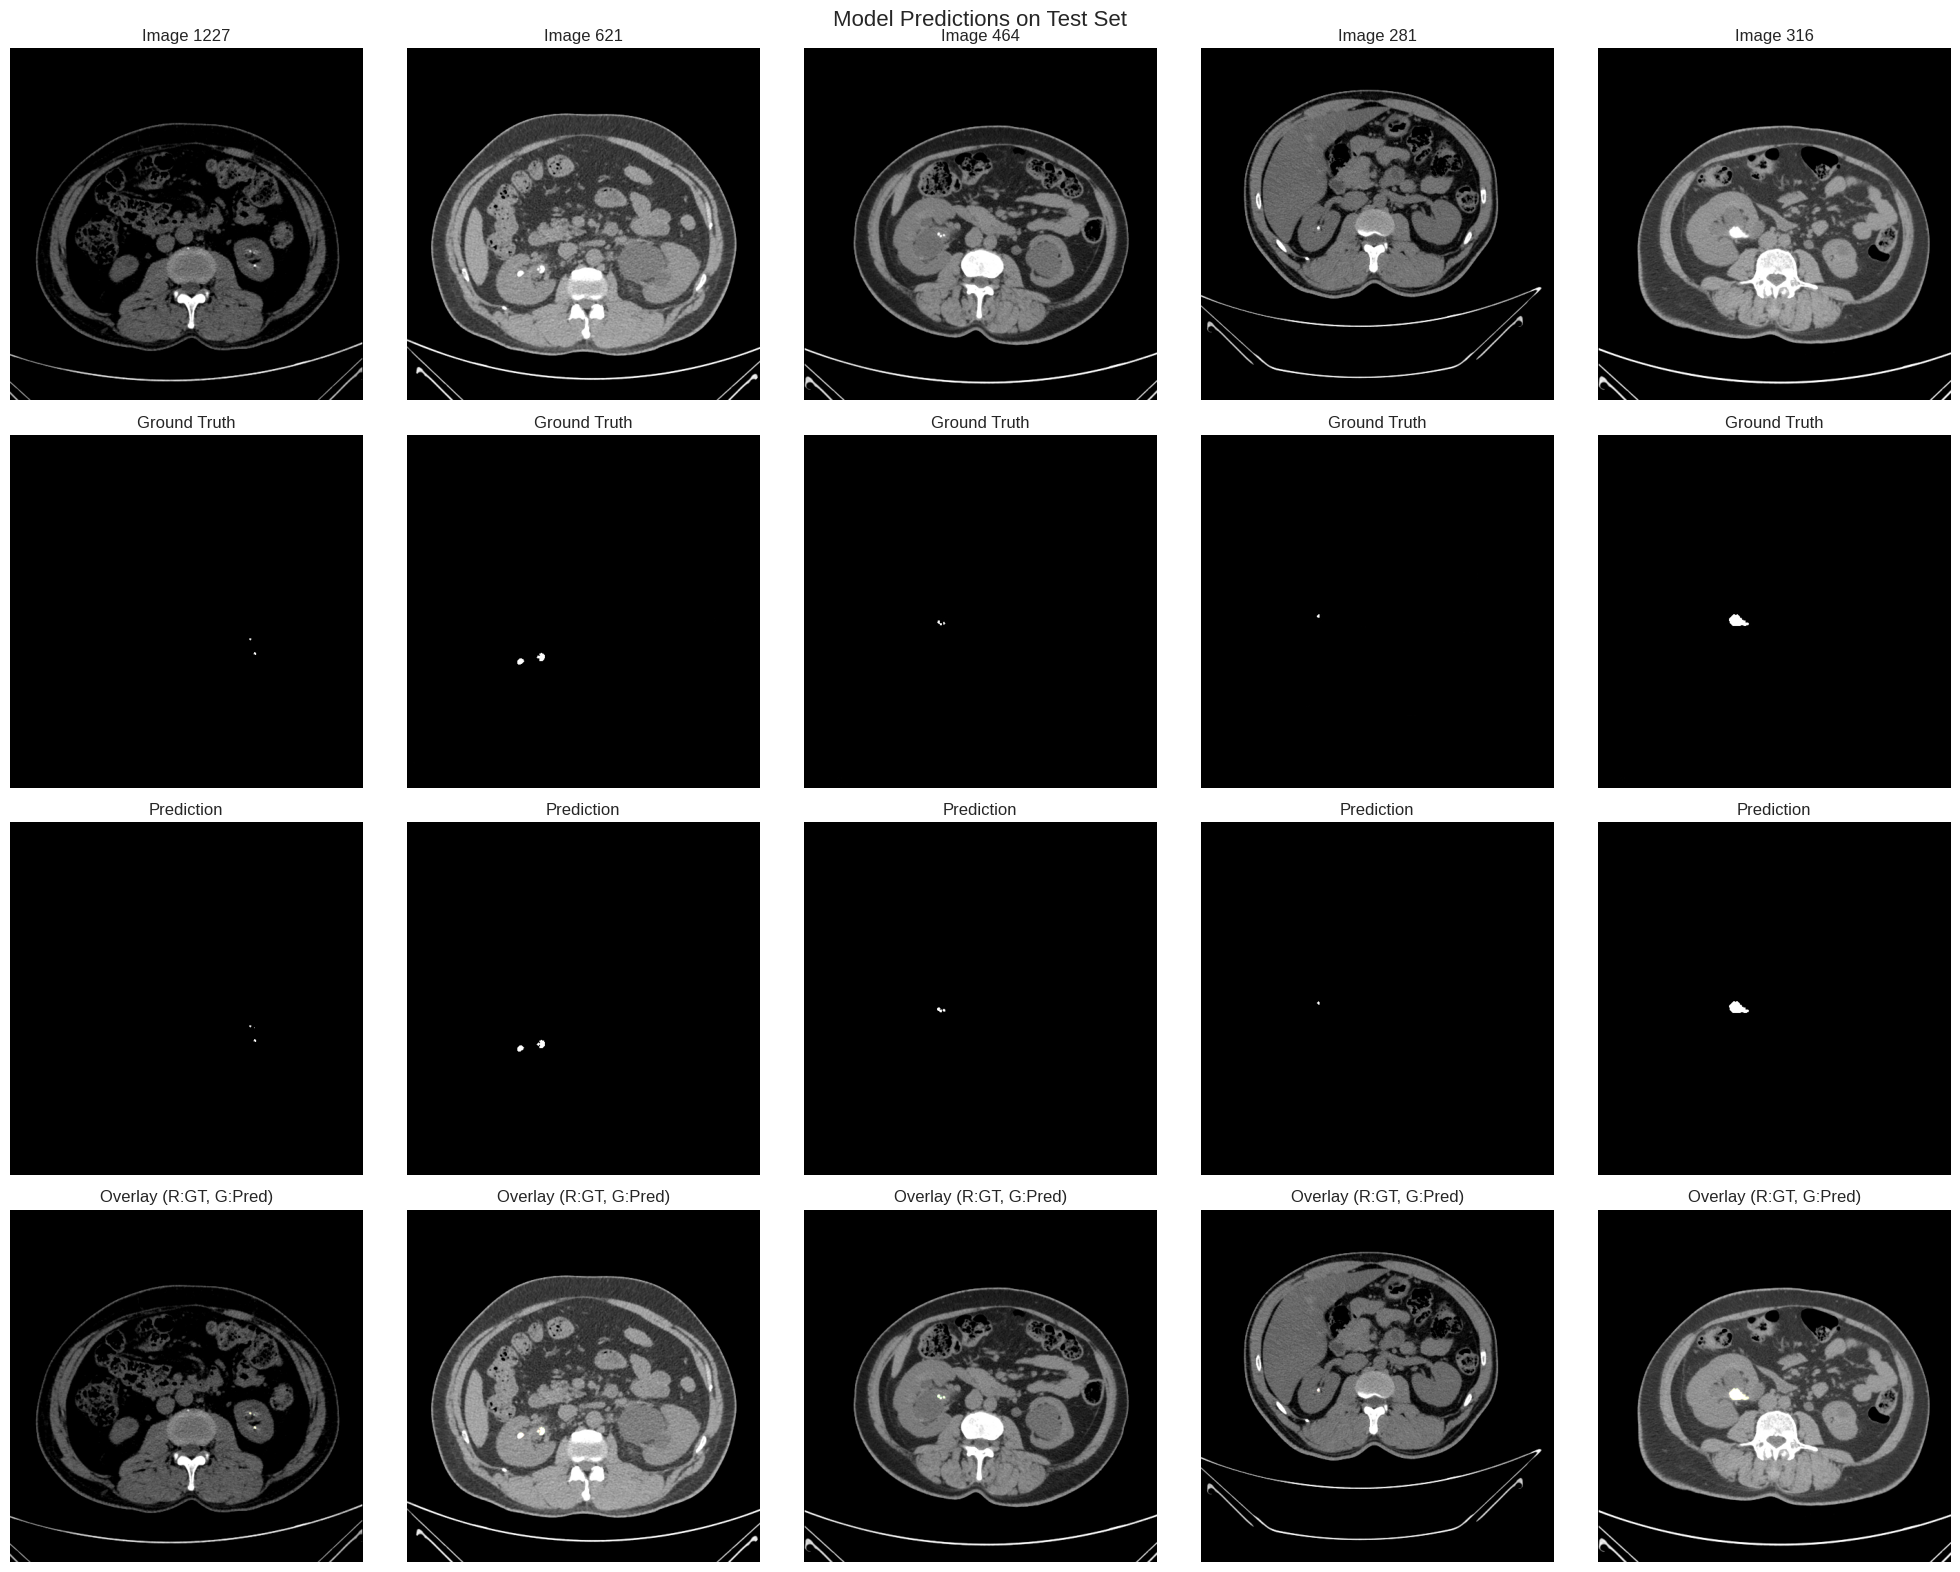

In [35]:
# Visualize predictions on test set (grayscale)
def visualize_predictions(model, dataset, indices, device, figsize=(16, 4)):
    """Visualize model predictions"""
    model.eval()
    
    n_samples = len(indices)
    fig, axes = plt.subplots(4, n_samples, figsize=(4*n_samples, 16))
    
    with torch.no_grad():
        for col, idx in enumerate(indices):
            image, mask, img_id = dataset[idx]
            image_batch = image.unsqueeze(0).to(device)
            
            # Get prediction (apply sigmoid since model outputs logits)
            pred = torch.sigmoid(model(image_batch))
            pred = pred.cpu().squeeze()
            pred_binary = (pred > 0.5).float()
            
            # Image is already normalized [0, 1], just squeeze
            img_np = image.squeeze().numpy()
            
            # Original image (grayscale)
            axes[0, col].imshow(img_np, cmap='gray')
            axes[0, col].set_title(f'Image {img_id}')
            axes[0, col].axis('off')
            
            # Ground truth mask
            axes[1, col].imshow(mask.squeeze().numpy(), cmap='gray')
            axes[1, col].set_title('Ground Truth')
            axes[1, col].axis('off')
            
            # Prediction
            axes[2, col].imshow(pred_binary.numpy(), cmap='gray')
            axes[2, col].set_title('Prediction')
            axes[2, col].axis('off')
            
            # Overlay (convert grayscale to RGB for overlay)
            img_rgb = np.stack([img_np, img_np, img_np], axis=-1)
            overlay = img_rgb.copy()
            mask_np = mask.squeeze().numpy()
            pred_np = pred_binary.numpy()
            # Red for ground truth, Green for prediction
            overlay[:, :, 0] = np.clip(overlay[:, :, 0] + 0.3 * mask_np, 0, 1)
            overlay[:, :, 1] = np.clip(overlay[:, :, 1] + 0.3 * pred_np, 0, 1)
            
            axes[3, col].imshow(overlay)
            axes[3, col].set_title('Overlay (R:GT, G:Pred)')
            axes[3, col].axis('off')
    
    plt.suptitle('Model Predictions on Test Set', fontsize=16)
    plt.tight_layout()
    plt.savefig(os.path.join(Config.OUTPUT_DIR, 'predictions.png'), dpi=150, bbox_inches='tight')
    plt.show()

# Visualize random test samples
random_indices = random.sample(range(len(test_dataset)), min(5, len(test_dataset)))
visualize_predictions(model, test_dataset, random_indices, Config.DEVICE)


Best Predictions (highest Dice):
     id  precision    recall   jaccard      dice
74  642   0.992212  0.992322  0.984653  0.992267
49  309   0.994653  0.989642  0.984405  0.992141
98  316   0.991677  0.992544  0.984344  0.992110

Worst Predictions (lowest Dice):
       id  precision    recall   jaccard      dice
116   875   0.996639  0.552656  0.551628  0.711031
56    493   0.538562  0.991485  0.536083  0.697987
60   1350   1.000000  0.470914  0.470914  0.640301

Best Predictions Visualization:


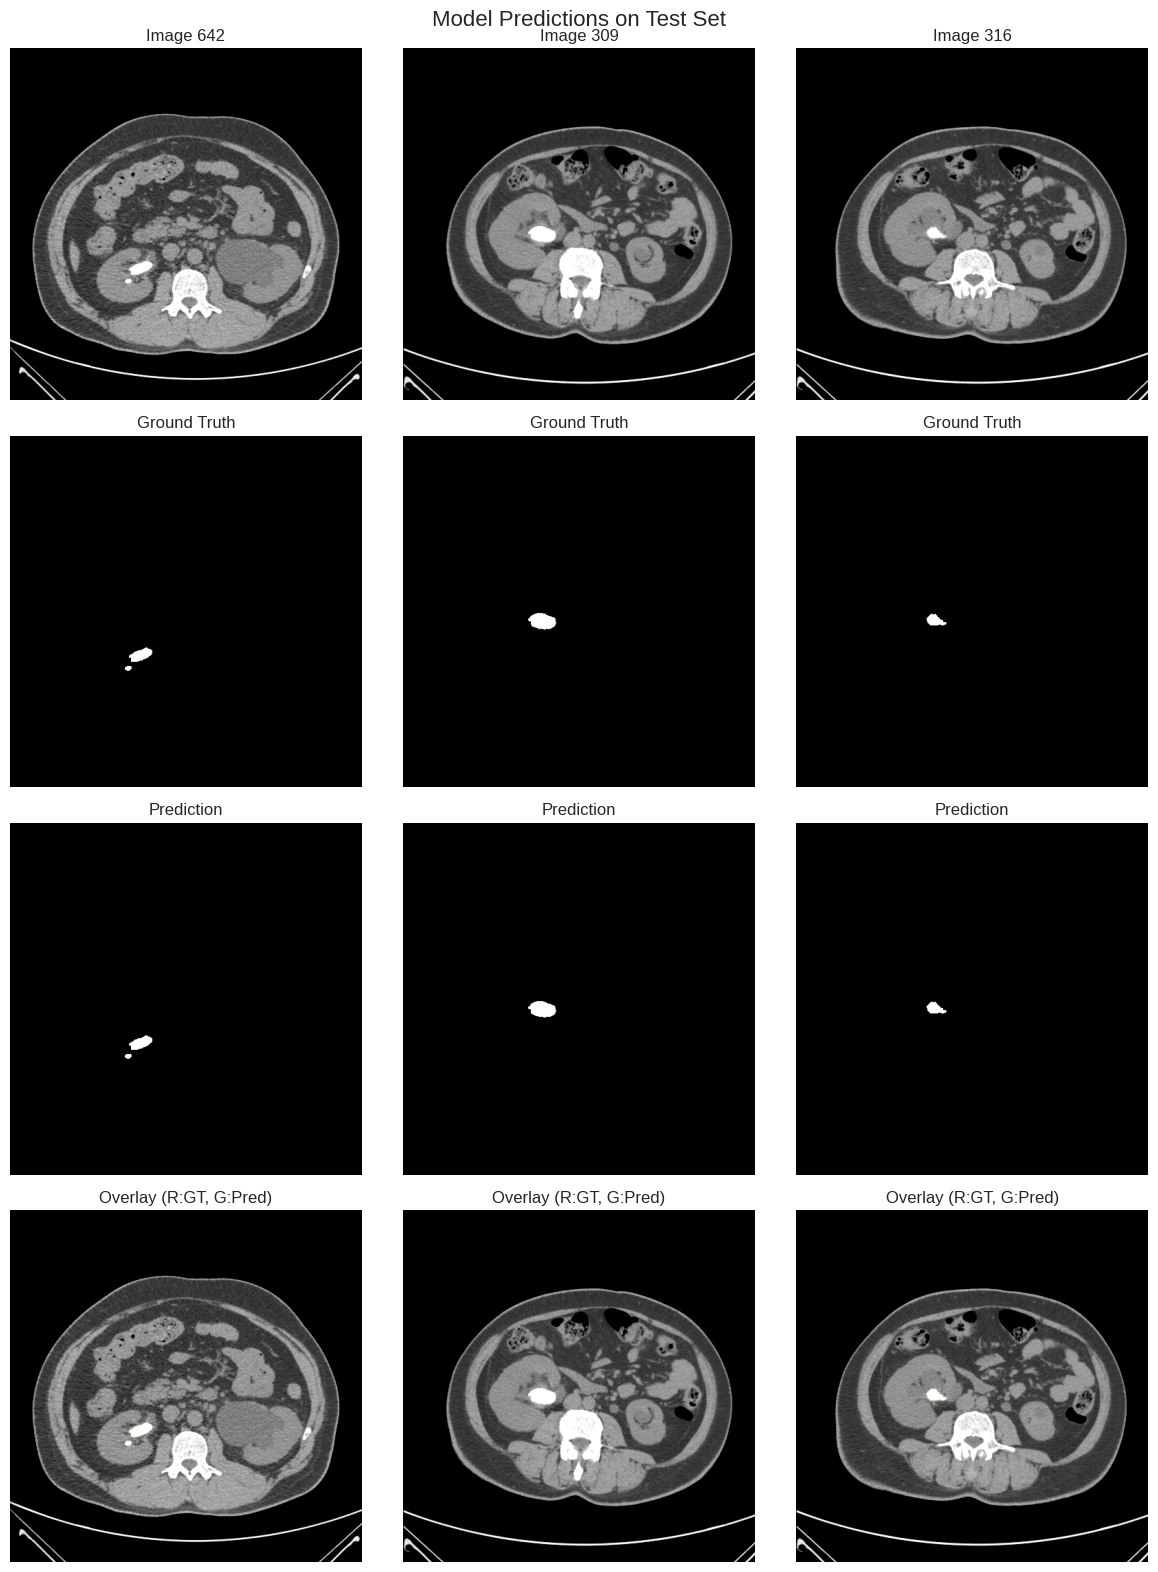


Worst Predictions Visualization:


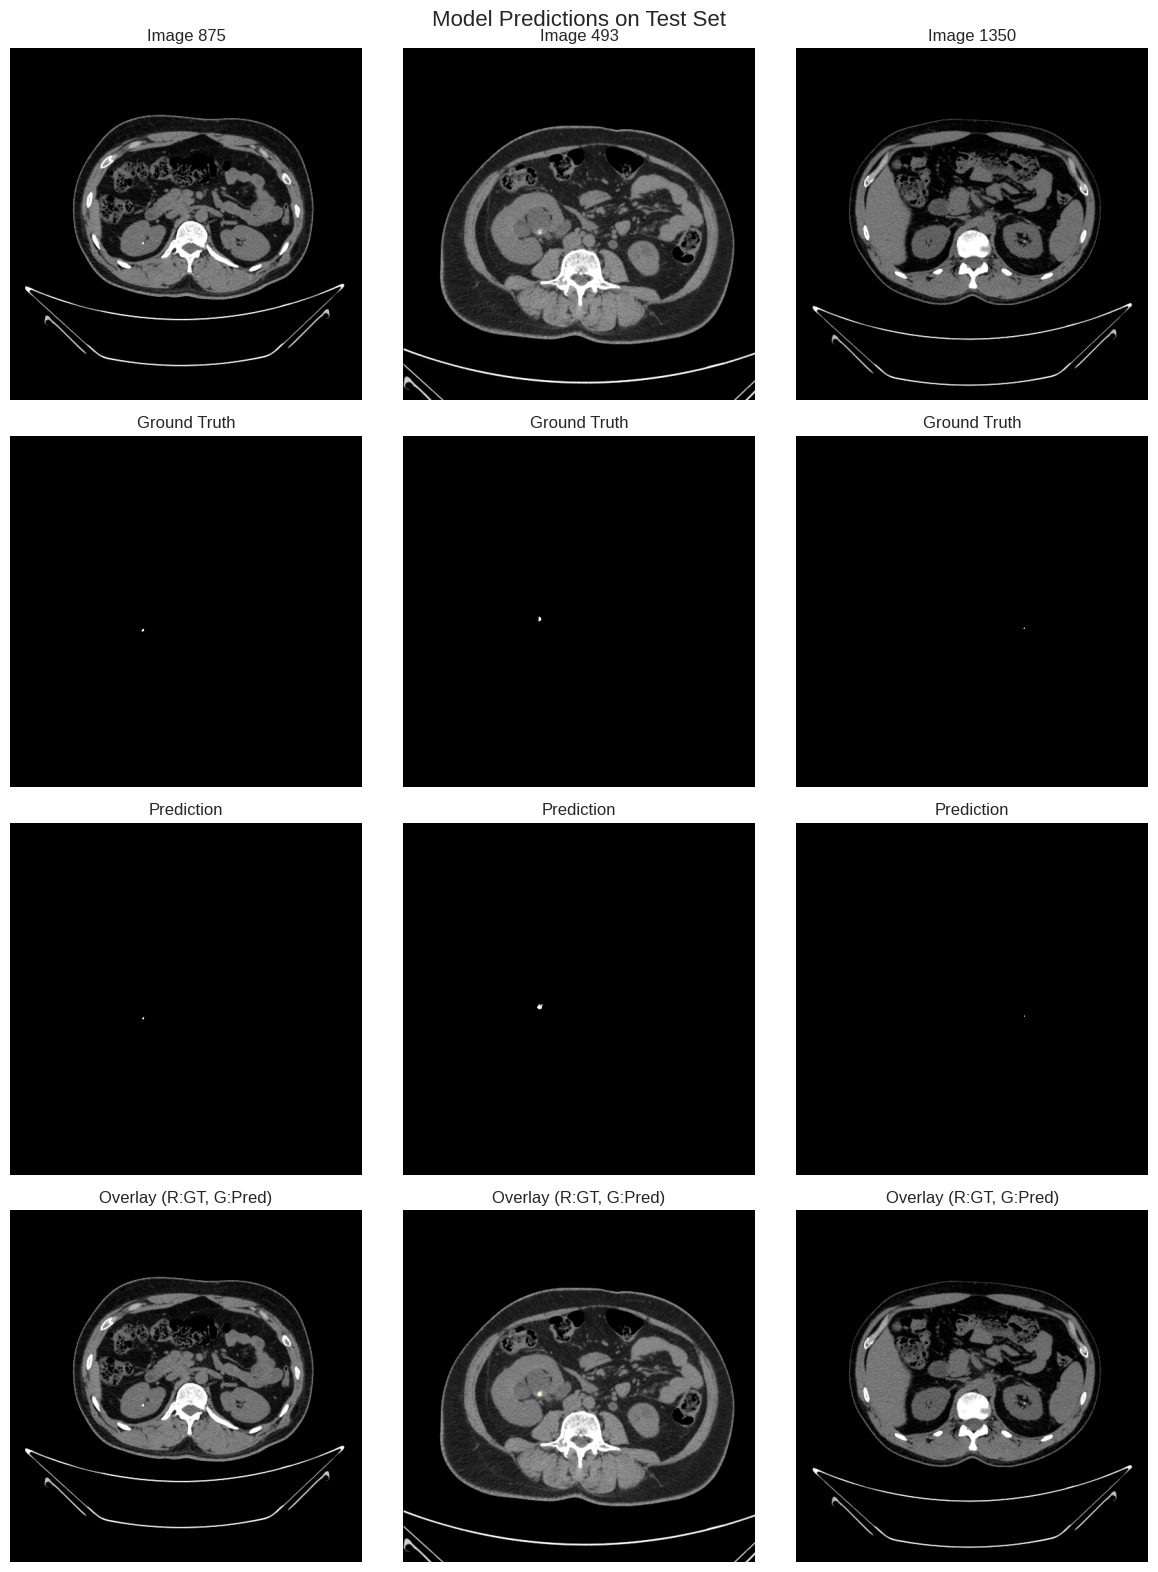

In [36]:
# Analyze best and worst predictions
def analyze_predictions(metrics_df, test_dataset, model, device, n_samples=3):
    """Analyze best and worst predictions"""
    # Sort by dice score
    sorted_df = metrics_df.sort_values('dice', ascending=False)
    
    print("\nBest Predictions (highest Dice):")
    print(sorted_df.head(n_samples)[['id', 'precision', 'recall', 'jaccard', 'dice']])
    
    print("\nWorst Predictions (lowest Dice):")
    print(sorted_df.tail(n_samples)[['id', 'precision', 'recall', 'jaccard', 'dice']])
    
    # Get indices for visualization
    id_to_idx = {test_dataset.image_ids[i]: i for i in range(len(test_dataset.image_ids))}
    
    best_ids = sorted_df.head(n_samples)['id'].tolist()
    worst_ids = sorted_df.tail(n_samples)['id'].tolist()
    
    best_indices = [id_to_idx[id] for id in best_ids if id in id_to_idx]
    worst_indices = [id_to_idx[id] for id in worst_ids if id in id_to_idx]
    
    if best_indices:
        print("\nBest Predictions Visualization:")
        visualize_predictions(model, test_dataset, best_indices[:3], device)
    
    if worst_indices:
        print("\nWorst Predictions Visualization:")
        visualize_predictions(model, test_dataset, worst_indices[:3], device)

analyze_predictions(metrics_df, test_dataset, model, Config.DEVICE)

## 10. Inference & Export

In [37]:
# Inference function for single image
def predict_single_image(model, image_path, device, image_size=512):
    """Predict segmentation mask for a single image"""
    model.eval()
    
    # Load image as grayscale
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    original_size = image.shape[:2]
    
    # Resize if needed
    if image.shape[0] != image_size or image.shape[1] != image_size:
        image_resized = cv2.resize(image, (image_size, image_size))
    else:
        image_resized = image
    
    # Normalize to [0, 1]
    image_norm = image_resized.astype(np.float32) / 255.0
    
    # Convert to tensor (1, 1, H, W)
    image_tensor = torch.from_numpy(image_norm).unsqueeze(0).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        pred = torch.sigmoid(model(image_tensor))  # Apply sigmoid
        pred = pred.cpu().squeeze().numpy()
    
    # Resize to original size
    pred_resized = cv2.resize(pred, (original_size[1], original_size[0]))
    pred_binary = (pred_resized > 0.5).astype(np.uint8)
    
    return pred_resized, pred_binary

# Example usage
sample_path = os.path.join(Config.IMAGE_DIR, f'{test_ids[0]}.tif')
pred_prob, pred_mask = predict_single_image(model, sample_path, Config.DEVICE)

print(f"Prediction shape: {pred_mask.shape}")
print(f"Unique values: {np.unique(pred_mask)}")

Prediction shape: (512, 512)
Unique values: [0 1]


In [39]:
# Save model and training results
print("\nSaving results...")

# Save training history
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(Config.OUTPUT_DIR, 'training_history.csv'), index=False)
print(f"  Training history saved to: {Config.OUTPUT_DIR}/training_history.csv")

# Save test metrics
metrics_df.to_csv(os.path.join(Config.OUTPUT_DIR, 'test_metrics.csv'), index=False)
print(f"  Test metrics saved to: {Config.OUTPUT_DIR}/test_metrics.csv")

# Save final summary
summary = {
    'model': Config.MODEL_NAME,
    'encoder': Config.ENCODER_NAME,
    'image_size': Config.IMAGE_SIZE,
    'batch_size': Config.BATCH_SIZE,
    'total_epochs': len(history['train_loss']),
    'best_epoch': checkpoint['epoch'] + 1,
    'test_loss': test_loss,
    'test_precision': test_metrics['precision'],
    'test_recall': test_metrics['recall'],
    'test_jaccard': test_metrics['jaccard'],
    'test_dice': test_metrics['dice']
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(Config.OUTPUT_DIR, 'model_summary.csv'), index=False)
print(f"  Model summary saved to: {Config.OUTPUT_DIR}/model_summary.csv")
print(f"  Best model saved to: {MODEL_SAVE_PATH}")

print("\nAll results saved successfully!")


Saving results...
  Training history saved to: /kaggle/working/training_history.csv
  Test metrics saved to: /kaggle/working/test_metrics.csv
  Model summary saved to: /kaggle/working/model_summary.csv
  Best model saved to: /kaggle/working/best_unetpp_model.pth

All results saved successfully!


In [40]:
# Final Summary
print("\n" + "=" * 70)
print("KIDNEY STONE SEGMENTATION - FINAL SUMMARY")
print("=" * 70)
print(f"\nModel: {Config.MODEL_NAME} with {Config.ENCODER_NAME} encoder")
print(f"Dataset: KSSD2025 ({len(matched_ids)} samples)")
print(f"Training: {len(train_ids)} | Validation: {len(val_ids)} | Test: {len(test_ids)}")
print(f"\nTraining Configuration:")
print(f"  - Image Size: {Config.IMAGE_SIZE}x{Config.IMAGE_SIZE}")
print(f"  - Batch Size: {Config.BATCH_SIZE}")
print(f"  - Learning Rate: {Config.LEARNING_RATE}")
print(f"  - Loss Function: Dice Loss")
print(f"  - Optimizer: Adam")
print(f"  - Epochs Trained: {len(history['train_loss'])}")
print(f"\nTest Set Performance:")
print(f"  - Precision: {test_metrics['precision']*100:.2f}%")
print(f"  - Recall: {test_metrics['recall']*100:.2f}%")
print(f"  - Jaccard (IoU): {test_metrics['jaccard']*100:.2f}%")
print(f"  - Dice Score: {test_metrics['dice']*100:.2f}%")
print("\n" + "=" * 70)
print("Reference: KSSD2025 Paper reported UNet++ Dice Score: 96.63%")
print("=" * 70)


KIDNEY STONE SEGMENTATION - FINAL SUMMARY

Model: UNetPlusPlus with resnet34 encoder
Dataset: KSSD2025 (838 samples)
Training: 586 | Validation: 126 | Test: 126

Training Configuration:
  - Image Size: 512x512
  - Batch Size: 4
  - Learning Rate: 0.0001
  - Loss Function: Dice Loss
  - Optimizer: Adam
  - Epochs Trained: 64

Test Set Performance:
  - Precision: 97.23%
  - Recall: 96.92%
  - Jaccard (IoU): 94.32%
  - Dice Score: 97.08%

Reference: KSSD2025 Paper reported UNet++ Dice Score: 96.63%
